# Numerical Solver for the Quantum Effective Potential (1D)

This notebook implements a full-chain numerical solver for the quantum effective potential $U_\text{eff}(q, \beta)$ in one dimension. The solver constructs and diagonalises the Hamiltonian matrix using a finite difference discretisation, yielding the eigenvalues $E_n$ and eigenfunctions $\psi_n(q)$ of the system. From these, the diagonal of the thermal density matrix is computed as

$$\langle q | e^{-\beta\hat{H}} | q \rangle = \sum_n |\psi_n(q)|^2 \, e^{-\beta E_n}$$

and the effective potential is recovered via

$$U_\text{eff}(q, \beta) = -\frac{1}{\beta} \ln \langle q | e^{-\beta\hat{H}} | q \rangle$$

**Atomic units are used throughout:** $\hbar = m = k_B = 1$.

The solver is validated against the exact analytical result for the quantum harmonic oscillator (QHO), for which $U_\text{eff}$ is known in closed form. This confirms numerical accuracy before applying the solver to two anharmonic systems (the quartic potential and the Morse potential) for which no closed-form solution exists. Results are computed across five temperatures spanning the quantum ($T < 1$) to near-classical ($T > 1$) regimes, with the classical potential $V(q)$ overlaid for reference. The numerical solutions of the solver are used to generate datasets for all subsequent ML notebooks.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
class QuantumSystem1D:
    """
    Quantum thermal density matrix calculator for 1D systems.
    Implements the formalism: ρ̂ = e^(-βH)/Z and computes effective potentials from
    the thermal density distribution.

    Uses atomic units: ℏ = m = ω = k_B = 1
    """

    def __init__(self, V, qmin, qmax, n_points, m=1.0, ℏ=1.0): # constructor
        """
        Initialize the quantum system by solving the eigenvalue problem.

        Parameters:
        -----------
        V: callable
            potential function V(q) that returns (V, dV/dq, d²V/dq²)

        qmin, qmax: float
            position grid boundaries

        n_points: int
            number of grid points

        m: float
            particle mass (default = 1.0, atomic units)

        ℏ: float
            reduced Planck constant (default = 1.0, atomic units)
        """
        # create variables to be stored in each relevant object
        # (so other functions in class can access these values!)
        self.V = V
        self.qmin = qmin
        self.qmax = qmax
        self.n_points = n_points
        self.m = m
        self.ℏ = ℏ

        # generate grid
        self.q_grid = np.linspace(qmin, qmax, n_points)
        self.q_delta = self.q_grid[1] - self.q_grid[0]

        # initialize eigenvalue solver function
        self._solve_eigenproblem()

    def _solve_eigenproblem(self):
        """Construct and diagonalize the Hamiltonian matrix using finite difference method."""
        H_matrix = np.zeros((self.n_points, self.n_points))

        # Hamiltonian: H = -ℏ²/(2m) d²/dq² + V(q)
        # Finite difference: T_ii = ℏ²/(m Δq²), T_i,i±1 = -ℏ²/(2m Δq²)
        kinetic_diag = self.ℏ**2 / (self.m * self.q_delta**2)
        kinetic_off = -self.ℏ**2 / (2.0 * self.m * self.q_delta**2)

        for i in range(self.n_points):
            for j in range(self.n_points):
                if i == j:
                    # diagonal terms = kinetic + potential
                    H_matrix[i, j] = kinetic_diag + self.V(self.q_grid[i])[0]
                elif i == j+1 or i == j-1:
                    # off-diagonal terms = kinetic coupling
                    H_matrix[i, j] = kinetic_off

        # solve eigenvalue problem
        eigenvalues, eigenvectors = np.linalg.eigh(H_matrix)

        # transpose eigenvectors for looping efficiency (rows = eigenvectors)
        eigenvectors = eigenvectors.T

        # normalize eigenvectors for discrete grid
        for i in range(len(eigenvectors)):
            norm = np.sqrt(np.trapz(eigenvectors[i]**2, self.q_grid))
            eigenvectors[i] /= norm

        # store results (keep absolute energies)
        self.eigenvalues = eigenvalues
        self.eigenvectors = eigenvectors

        print(f"Solved eigenvalue problem: {self.n_points} states computed")
        print(f"Ground state energy: E₀ = {eigenvalues[0]:.6f}")
        print(f"First excited state: E₁ = {eigenvalues[1]:.6f}")

    def partition_function(self, β):
        """
        Compute the partition function Z = Tr(e^(-βH)) = Σₙ e^(-β Eₙ) (trace of thermal density matrix)

        Parameters:
        -----------
        β: float
            coldness (β = 1/T, with k_B = 1)

        Returns:
        --------
        Z: float
            partition function
        """
        return np.sum(np.exp(-β * self.eigenvalues))

    def thermal_density_diagonal(self, β):
        """
        Compute the diagonal elements of the thermal density matrix in position basis.
        ⟨q|e^(-βH)|q⟩ = Σₙ |ψₙ(q)|² e^(-β Eₙ)

        This is the unnormalized quantum thermal density.

        Parameters:
        -----------
        β: float
            coldness (β = 1/T, with k_B = 1)

        Returns:
        --------
        diagonal: ndarray
            unnormalized thermal density ⟨q|e^(-βH)|q⟩ for all q
        """
        diagonal = np.zeros_like(self.q_grid)  #creates array of zeros with same shape as q_grid

        # sum over all eigenstates - |ψₙ(q)|² × e^(-β Eₙ)
        for E, psi in zip(self.eigenvalues, self.eigenvectors): #pair up elements of two lists
            diagonal += psi**2 * np.exp(-β * E)  #add weighted contribution from each eigenstate

        return diagonal

    def quantum_probability(self, β):
        """
        Calculate normalized quantum thermal probability distribution.
        P(q, β) = ⟨q|e^(-βH)|q⟩ / Z

        Parameters:
        -----------
        β: float
            coldness (β = 1/T, with k_B = 1)

        Returns:
        --------
        probability: ndarray
            normalized probability distribution P(q, β)
        """
        diagonal = self.thermal_density_diagonal(β)
        Z = self.partition_function(β)

        return diagonal / Z

    def classical_probability(self, β):
        """
        Calculate classical Boltzmann probability distribution.
        P(q) ∝ exp(-βV(q))

        Parameters:
        -----------
        β: float
            coldness (β = 1/T, with k_B = 1)

        Returns:
        --------
        probability: ndarray
            normalized classical probability P(q) ∝ exp(-βV(q))
        """
        # calculate potential at all grid points
        V_values = np.array([self.V(q)[0] for q in self.q_grid])

        # classical Boltzmann distribution
        probability = np.exp(-β * V_values)

        # normalize using trapezoidal integration
        Z = np.trapz(probability, self.q_grid)

        return probability / Z

    def effective_potential_quantum(self, β):
        """
        Compute quantum effective potential from thermal density matrix.
        U_eff(q, β) = -(1/β) ln⟨q|e^(-βH)|q⟩

        Note: Constant offset (free energy) is removed by setting U_eff(q=0) = 0
              to match analytical convention for symmetric potentials.

        Parameters:
        -----------
        β: float
            coldness (β = 1/T, with k_B = 1)

        Returns:
        --------
        U_eff: ndarray
            quantum effective potential U_eff(q, β) = -(1/β) ln⟨q|e^(-βH)|q⟩
        """
        diagonal = self.thermal_density_diagonal(β)

        # avoid log(0) by adding small epsilon
        eps = 1e-300
        diagonal_safe = np.maximum(diagonal, eps)

        U_eff = -(1.0/β) * np.log(diagonal_safe)

        # remove constant offset by setting U_eff(q=0) = 0 (matches analytical convention)
        # for symmetric potentials, minimum is at q=0
        q_zero_idx = np.argmin(np.abs(self.q_grid))
        offset = U_eff[q_zero_idx] # value of U_eff at q=0 (constant shift)
        U_eff = U_eff - offset

        return U_eff

    def effective_potential_classical(self, β):
        """
        Compute classical effective potential.
        U_eff(q, β) = V(q) for low β (classical limit)

        Parameters:
        -----------
        β: float
            coldness (β = 1/T, with k_B = 1)

        Returns:
        --------
        U_eff: ndarray
            classical effective potential (just the potential V(q))
        """
        # in the classical limit, U_eff = V(q)
        V_values = np.array([self.V(q)[0] for q in self.q_grid])

        return V_values

    def compute_all(self, T, method='quantum'):
        """
        Convenience method to compute probability and effective potential.

        Parameters:
        -----------
        T: float
            temperature (k_B = 1)
        method: str
            'quantum' or 'classical'

        Returns:
        --------
        probability: ndarray
            normalized probability distribution
        U_eff: ndarray
            effective potential
        Z: float (only for quantum)
            partition function (only returned for quantum method)
        """
        β = 1.0 / T

        if method == 'quantum':
            prob = self.quantum_probability(β)
            U_eff = self.effective_potential_quantum(β)
            Z = self.partition_function(β)
            return prob, U_eff, Z
        elif method == 'classical':
            prob = self.classical_probability(β)
            U_eff = self.effective_potential_classical(β)
            return prob, U_eff
        else:
            raise ValueError("method must be 'quantum' or 'classical'")


The thermal density matrix of a QHO centred at $q_0$ in the position basis is given by

$$\rho_{\text{harm}}(q,\beta) = \sqrt{\frac{m\omega}{2\pi\hbar\sinh(\beta\hbar\omega)}}
\exp\!\left(-\frac{m\omega(q - q_0)^2}{\hbar} \tanh\!\left(\frac{\beta\hbar\omega}{2}\right)\right),
\quad \beta = \frac{1}{k_B T}$$

Setting $q_0 = 0$ and taking $U_{\text{eff}} = -\frac{1}{\beta}\ln\rho(q)$, we obtain

$$U_{\text{eff}}(q,\beta) = \frac{m\omega q^2}{\hbar\beta}\tanh\!\left(\frac{\beta\hbar\omega}{2}\right) - \frac{1}{2\beta}\ln\!\left(\frac{m\omega}{2\pi\hbar\sinh(\beta\hbar\omega)}\right)$$

The second term is a position-independent free-energy offset equal to $U_{\text{eff}}(0)$. The expression is shifted by this constant so that $U_{\text{eff}}(0) = 0$, which is equivalent to dropping the second term entirely. This matches the convention used by the numerical solver and has no effect on the shape of the potential. The zeroing convention and dropping the constant term are equivalent for the QHO, and equivalent up to numerical precision for the solver.


In [25]:
# defines a harmonic potential

def V_harmonic(q):  # ½kq², where k = mω²
    k = 1
    return 0.5 * k * q**2, k * q, k * q**0  # return V, dV/dq, d²V/dq²

In [4]:
# analytical effective potential for QHO, centred at (q=0, U=0)
def U_eff_analytical(q, T, m=1.0, ω=1.0, ℏ=1.0, k=1.0):
    """
    Analytical effective potential for the QHO, centred so that U_eff(0) = 0,
    matching the convention used by the numerical solver.

    Parameters:
    -----------
    q: array_like
        Position(s)
    T: float
        Temperature (with k_B = 1)
    m: float
        Mass (atomic units)
    ω: float
        Angular frequency (atomic units)
    ℏ: float
        Reduced Planck constant (atomic units)
    k: float
        Spring constant

    Returns:
    --------
    U_eff : array_like
        Effective potential at position(s) q and temperature T, with U_eff(0) = 0
    """
    β = 1.0 / T

    # centred expression: constant free-energy offset removed so U_eff(q=0) = 0
    return (m * ω / (β * ℏ)) * np.tanh(β * ℏ * ω / 2) * q**2


/tmp/ipykernel_2783/395177167.py:73: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm = np.sqrt(np.trapz(eigenvectors[i]**2, self.q_grid))
/tmp/ipykernel_2783/395177167.py:167: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Z = np.trapz(probability, self.q_grid)


Solved eigenvalue problem: 200 states computed
Ground state energy: E₀ = 0.499684
First excited state: E₁ = 1.498420


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

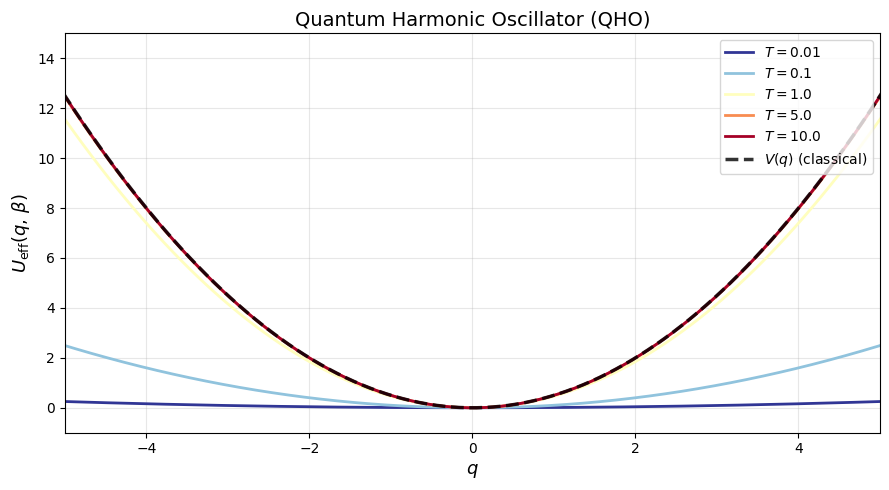

In [24]:
# initialise the quantum system (solves eigenvalue problem once)
qho_system = QuantumSystem1D(V_harmonic, qmin=-10, qmax=10, n_points=200, m=1.0, ℏ=1.0)

# plot: quantum U_eff at 5 temperatures vs classical V(q) for QHO
temperatures_to_plot = [0.01, 0.1, 1.0, 5.0, 10.0]
n = len(temperatures_to_plot)
colors = [plt.cm.RdYlBu_r(i / (n - 1)) for i in range(n)]

fig, ax = plt.subplots(figsize=(9, 5))

for T, color in zip(temperatures_to_plot, colors):
    _, U_eff_T, _ = qho_system.compute_all(T, method='quantum')
    ax.plot(qho_system.q_grid, U_eff_T, label=rf'$T = {T}$', linewidth=2, color=color)

_, U_eff_class = qho_system.compute_all(1.0, method='classical')
# shift classical to same zero convention
V_class_vals = np.array([V_harmonic(q)[0] for q in qho_system.q_grid])
q_zero_idx = np.argmin(np.abs(qho_system.q_grid))
V_class_vals -= V_class_vals[q_zero_idx]
ax.plot(qho_system.q_grid, V_class_vals, label=r'$V(q)$ (classical)',
        linewidth=2.5, color='black', linestyle='--', alpha=0.8)

ax.set_xlabel(r'$q$', fontsize=13)
ax.set_ylabel(r'$U_\mathrm{eff}(q,\,\beta)$', fontsize=13)
ax.set_title(r'Quantum Harmonic Oscillator (QHO)', fontsize=14)
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_xlim(-5, 5)
ax.set_ylim(-1, 15)
plt.tight_layout()
plt.savefig('QHO-Ueff.pdf', bbox_inches='tight', dpi=300)
from google.colab import files
files.download('QHO-Ueff.pdf')

plt.show()


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

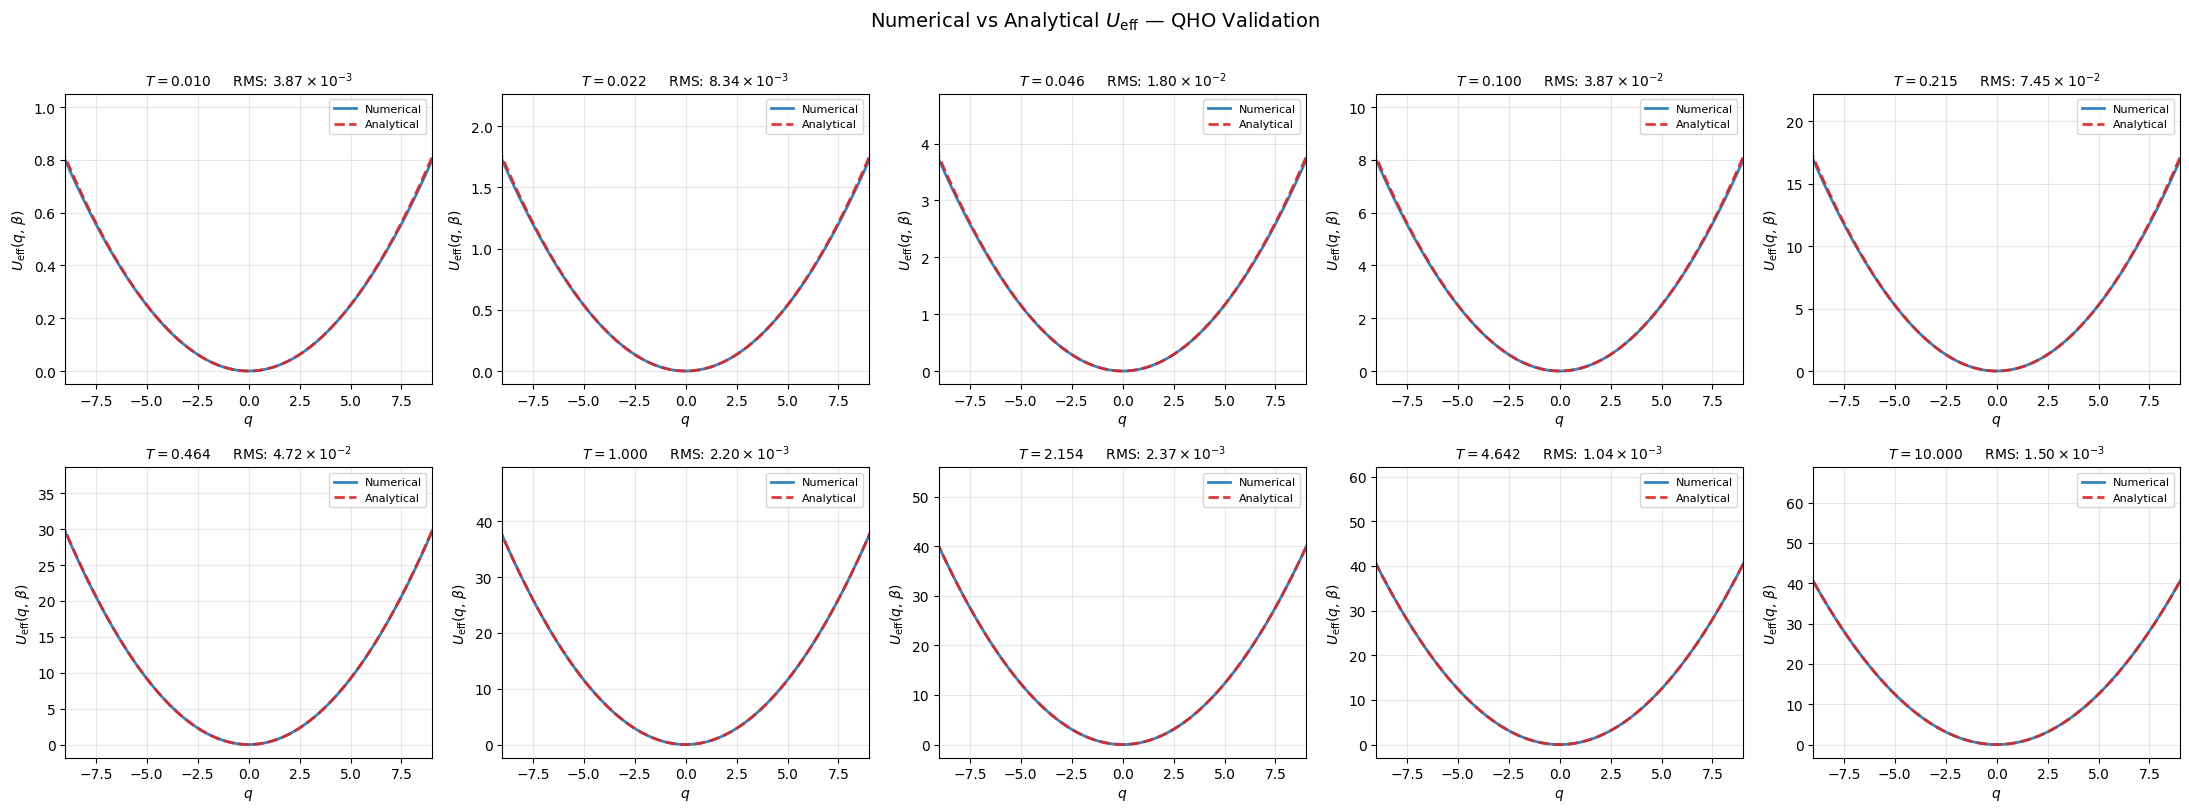

In [20]:
# plot: numerical vs analytical U_eff (2×5 validation grid, 10 log-spaced temperatures)
test_temperatures = np.logspace(np.log10(0.01), np.log10(10), 10)

fig, axes = plt.subplots(2, 5, figsize=(22, 8))
axes = axes.flatten()

for idx, T in enumerate(test_temperatures):
    _, U_eff_numerical, _ = qho_system.compute_all(T, method='quantum')
    U_eff_analytical_vals  = U_eff_analytical(qho_system.q_grid, T)

    mask      = np.abs(qho_system.q_grid) < 9
    diff      = U_eff_numerical[mask] - U_eff_analytical_vals[mask]
    rms_error = np.sqrt(np.mean(diff**2))

    axes[idx].plot(qho_system.q_grid, U_eff_numerical, linewidth=2,
                   label='Numerical', color='#1f77b4', alpha=0.9)
    axes[idx].plot(qho_system.q_grid, U_eff_analytical_vals, linewidth=2,
                   label='Analytical', color='#d62728', linestyle='--', alpha=0.9)


    exp   = int(np.floor(np.log10(abs(rms_error))))
    coeff = rms_error / 10**exp
    axes[idx].set_title(rf'$T = {T:.3f}$ $\quad$ RMS: ${coeff:.2f} \times 10^{{{exp}}}$', fontsize=10)

    axes[idx].set_xlabel(r'$q$', fontsize=10)
    axes[idx].set_ylabel(r'$U_\mathrm{eff}(q,\,\beta)$', fontsize=10)
    axes[idx].legend(fontsize=8)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_xlim(-9, 9)

plt.suptitle(r'Numerical vs Analytical $U_\mathrm{eff}$ — QHO Validation',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('QHO-Numerical-Analytical-Ueff.pdf', bbox_inches='tight', dpi=300)
from google.colab import files
files.download('QHO-Numerical-Analytical-Ueff.pdf')
plt.show()


# Quartic & Morse Potentials

### The Quartic Potential is given by:

$$V_{\text{quartic}}(q) = \frac{1}{2}k q^2 + \frac{1}{4}\lambda q^4$$

- k is the usual 'spring' constant.

- $λ$ is the anharmonicity coefficient, essentially determining how far the potential deviates from a QHO.


### The Morse Potential is an empirical potential energy function typically used to model the vibrational structure and dissociation of diatomic molecules. It is given by:

$$V_{\text{Morse}}(q) = D_e \left(1 - e^{-a(q - q_e)}\right)^2$$

- $D_e$ is the dissociation energy, representing the depth of the potential well from the minimum to zero energy.

- $q_e$ is the equilibrium particle bond length, the distance where the potential energy is at its minimum (bottom of the well).

- a is constant that determines the width and steepness of the potential well, related to the vibrational frequency of the system.

In [7]:
def V_quartic(q, k=1.0, λ=0.1):
    V   = 0.5 * k * q**2 + 0.25 * λ * q**4
    dV  = k * q + λ * q**3
    d2V = k + 3 * λ * q**2
    return V, dV, d2V

def V_morse(q, D_e=10.0, a=1.0, q_e=0.0):
    e   = np.exp(-a * (q - q_e))
    V   = D_e * (1 - e)**2
    dV  = 2 * D_e * a * e * (1 - e)
    d2V = 2 * D_e * a**2 * e * (2*e - 1)
    return V, dV, d2V

quartic_system = QuantumSystem1D(
    V=lambda q: V_quartic(q, k=1.0, λ=0.1),
    qmin=-8, qmax=8, n_points=200)

morse_system = QuantumSystem1D(
    V=lambda q: V_morse(q, D_e=10.0, a=1.0, q_e=0.0),
    qmin=-2, qmax=10, n_points=200)

Solved eigenvalue problem: 200 states computed
Ground state energy: E₀ = 0.517139
First excited state: E₁ = 1.582396
Solved eigenvalue problem: 200 states computed
Ground state energy: E₀ = 2.109122
First excited state: E₁ = 5.577158


/tmp/ipykernel_2783/395177167.py:73: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm = np.sqrt(np.trapz(eigenvectors[i]**2, self.q_grid))


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

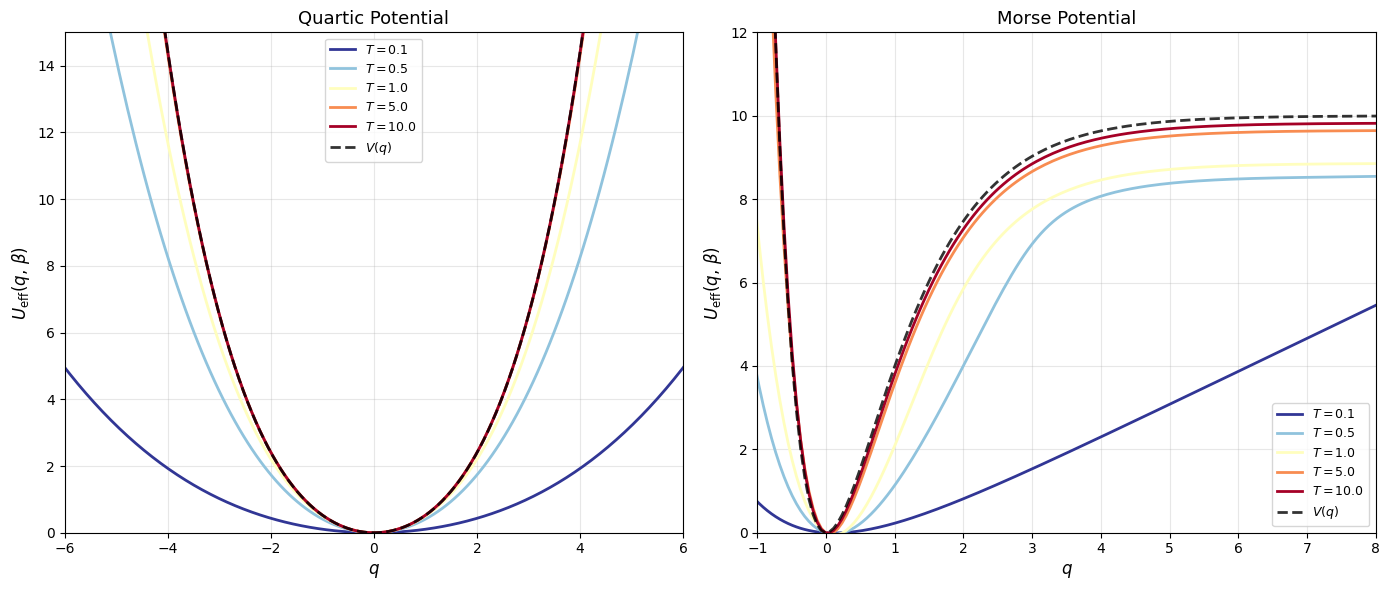

In [19]:
# plot: quantum U_eff at 10 temperatures vs classical V(q) for the Quartic and Morse Potentials

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
temperatures_to_plot = [0.1, 0.5, 1.0, 5.0, 10.0]
n = len(temperatures_to_plot)
colors = [plt.cm.RdYlBu_r(i / (n - 1)) for i in range(n)]

configs = [
    (quartic_system, r'Quartic Potential', (-6, 6),  (0, 15)),
    (morse_system,   r'Morse Potential',   (-1, 8),  (0, 12)),
]

for ax, (system, title, xlim, ylim) in zip(axes, configs):
    for T, color in zip(temperatures_to_plot, colors):
        _, U_eff_T, _ = system.compute_all(T, method='quantum')
        ax.plot(system.q_grid, U_eff_T, label=rf'$T = {T}$', lw=2, color=color)

    V_vals = np.array([system.V(q)[0] for q in system.q_grid])
    ax.plot(system.q_grid, V_vals - V_vals.min(), 'k--', lw=2,
            label=r'$V(q)$', alpha=0.8)

    ax.set_xlabel(r'$q$', fontsize=12)
    ax.set_ylabel(r'$U_\mathrm{eff}(q,\,\beta)$', fontsize=12)
    ax.set_title(title, fontsize=13)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)

plt.tight_layout()
plt.savefig('anharmonic-potentials-Ueff.pdf', bbox_inches='tight', dpi=300)
from google.colab import files
files.download('anharmonic-potentials-Ueff.pdf')
plt.show()
